<a href="https://colab.research.google.com/github/rafaelmenesesw-cpu/Geomodelagem/blob/main/Atividade_feita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instala o ultralytics e o roboflow atualizando o setuptools para evitar conflitos
!pip install roboflow ultralytics

# Força a reinstalação segura de dependências do PyTorch se necessário
# (Geralmente apenas reiniciar o ambiente após o pip install acima já resolve)

In [2]:
import os
from roboflow import Roboflow
from ultralytics import YOLO

# --- CONFIGURAÇÃO ÚNICA DA SUA IDENTIDADE ---
API_KEY = "urxTgqw5sDeeFf9AXeZT"
WORKSPACE = "rafaels-workspace-solhy"
PROJECT_NAME = "acai-zwrcf"
VERSION_NUMBER = 2  # Versão 2 que contém Açaí e Barbeiro

# Inicializando o Roboflow e baixando o dataset atualizado
rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT_NAME)
version = project.version(VERSION_NUMBER)
dataset = version.download("yolov11")

print(f"\nDataset baixado com sucesso em: {dataset.location}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Açaí-2 in yolov11:: 100%|██████████| 145/145 [00:00<00:00, 6076.88it/s]


Dataset baixado com sucesso em: /content/Açaí-2


In [3]:
from ultralytics import YOLO
import os

# Carrega o modelo YOLO11 Extra Large de segmentação (máximo poder de detecção)
model = YOLO("yolo11x-seg.pt")

# Treinamento focado em objetos difíceis e pequenos (Barbeiro)
model.train(
    data=os.path.join(dataset.location, "data.yaml"),
    epochs=100,         # 100 épocas dá o tempo ideal para estabilizar o aprendizado das duas classes
    imgsz=640,          # Resolução ideal
    batch=8,            # Ajustado para o modelo XL rodar na GPU do Colab sem estourar memória
    workers=4,
    project="usmb-3ou0v",
    name="exp_acai_barbeiro_max_precision",

    # --- HIPERPARÂMETROS DE REFINAMENTO CRÍTICO ---
    patience=20,        # Evita parada precoce se o modelo ainda estiver evoluindo
    box=8.5,            # Melhora o ajuste milimétrico dos contornos/máscaras
    cls=2.0,            # Dobra a punição para quando o modelo ignora ou erra a classe de um objeto

    # Técnicas de Augmentation (Aumento de dados artificial)
    mosaic=1.0,         # Cria colagens de imagens para treinar detecção de objetos bem pequenos
    mixup=0.2,          # Mescla sobreposições para ajudar em fundos poluídos/camuflados
    scale=0.6,          # Força o modelo a aprender com zoom in e zoom out
    degrees=30.0,       # Rotaciona imagens para aprender em qualquer ângulo
    fliplr=0.5          # Inverte imagens horizontalmente
)

Ultralytics 8.4.87 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=8.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Açaí-2/data.yaml, degrees=30.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11x-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_acai_barbeiro_max_precision, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e6d8efcd6d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04

[INFO] Testando 5 imagens com filtros de sensibilidade máxima...

--- [Foto 1] images-9-_jpg.rf.3ecefa632f5eea14a6f234b3d50e8d09.jpg ---

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 /content/Açaí-2/valid/images/images-9-_jpg.rf.3ecefa632f5eea14a6f234b3d50e8d09.jpg: 640x640 2 acais, 5 barbeiros, 112.1ms
Speed: 3.4ms preprocess, 112.1ms inference, 15.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
   ↳ acai detectado! Confiança: 0.33
   ↳ barbeiro detectado! Confiança: 0.18
   ↳ acai detectado! Confiança: 0.15
   ↳ barbeiro detectado! Confiança: 0.15
   ↳ barbeiro detectado! Confiança: 0.14
   ↳ barbeiro detectado! Confiança: 0.13
   ↳ barbeiro detectado! Confiança: 0.10
   🎉 Perfeito! Açaí E Barbeiro encontrados na mesma imagem.


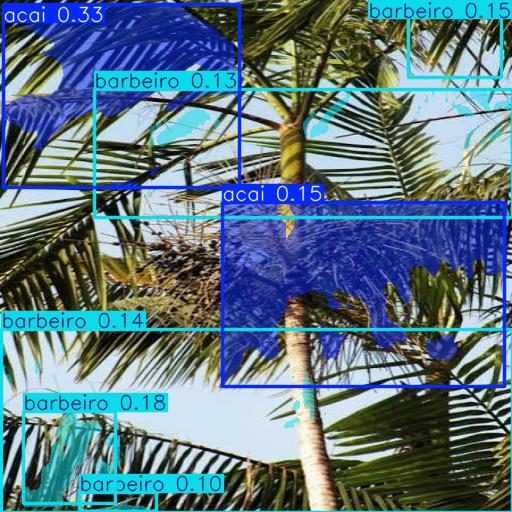

------------------------------------------------------------
--- [Foto 2] images-3-_jpg.rf.c787ca065ba1a455d1dbf8b2eb58c3a7.jpg ---

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 /content/Açaí-2/valid/images/images-3-_jpg.rf.c787ca065ba1a455d1dbf8b2eb58c3a7.jpg: 640x640 3 acais, 75.1ms
Speed: 3.8ms preprocess, 75.1ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
   ↳ acai detectado! Confiança: 0.19
   ↳ acai detectado! Confiança: 0.17
   ↳ acai detectado! Confiança: 0.10
   ⚠️ Apenas o Açaí foi visto. O Barbeiro sumiu ou não existe nesta foto.


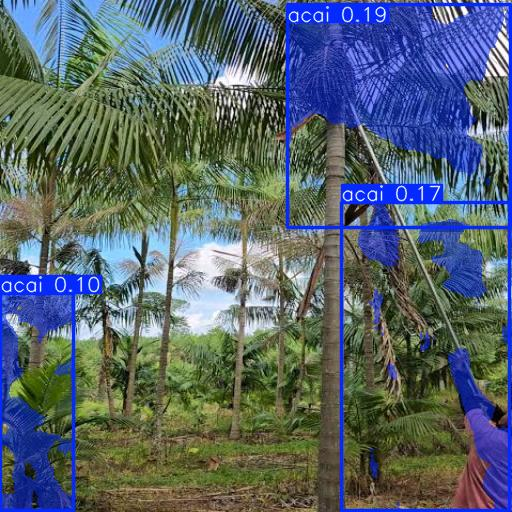

------------------------------------------------------------
--- [Foto 3] WhatsApp-Image-2026-07-03-at-11-43-25_jpeg.rf.99759e95f823f9d58d1733b4702f4538.jpg ---

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 /content/Açaí-2/valid/images/WhatsApp-Image-2026-07-03-at-11-43-25_jpeg.rf.99759e95f823f9d58d1733b4702f4538.jpg: 640x640 1 acai, 1 barbeiro, 72.1ms
Speed: 5.7ms preprocess, 72.1ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
   ↳ acai detectado! Confiança: 0.15
   ↳ barbeiro detectado! Confiança: 0.11
   🎉 Perfeito! Açaí E Barbeiro encontrados na mesma imagem.


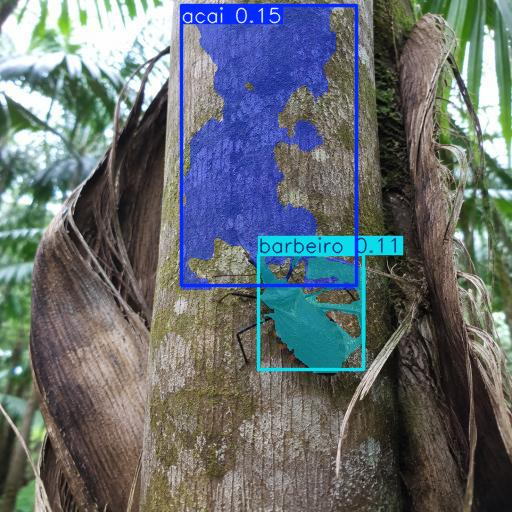

------------------------------------------------------------
--- [Foto 4] images-7-_jpg.rf.8291b3d72b459d142bd68c2bc399e24a.jpg ---

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 /content/Açaí-2/valid/images/images-7-_jpg.rf.8291b3d72b459d142bd68c2bc399e24a.jpg: 640x640 1 acai, 2 barbeiros, 75.0ms
Speed: 4.7ms preprocess, 75.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
   ↳ barbeiro detectado! Confiança: 0.40
   ↳ acai detectado! Confiança: 0.14
   ↳ barbeiro detectado! Confiança: 0.13
   🎉 Perfeito! Açaí E Barbeiro encontrados na mesma imagem.


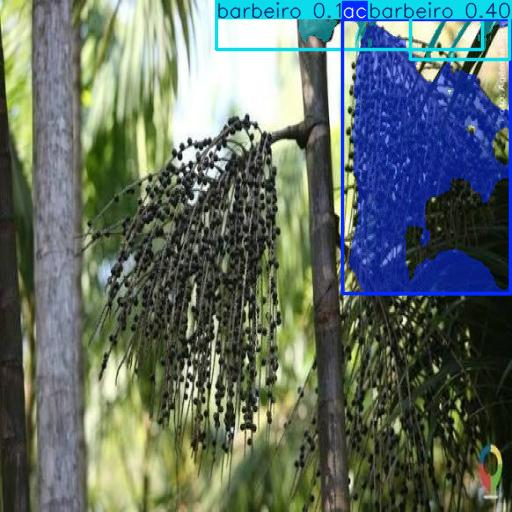

------------------------------------------------------------
--- [Foto 5] WhatsApp-Image-2026-07-03-at-12-01-13-2-_jpeg.rf.c54f606f2b5196e823b70f7864872339.jpg ---

WARNING ⚠️ Model does not support 'augment=True', reverting to single-scale prediction.
image 1/1 /content/Açaí-2/valid/images/WhatsApp-Image-2026-07-03-at-12-01-13-2-_jpeg.rf.c54f606f2b5196e823b70f7864872339.jpg: 640x640 1 barbeiro, 75.2ms
Speed: 4.0ms preprocess, 75.2ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
   ↳ barbeiro detectado! Confiança: 0.41
   ⚠️ Apenas o Barbeiro foi visto. O Açaí sumiu ou não existe nesta foto.


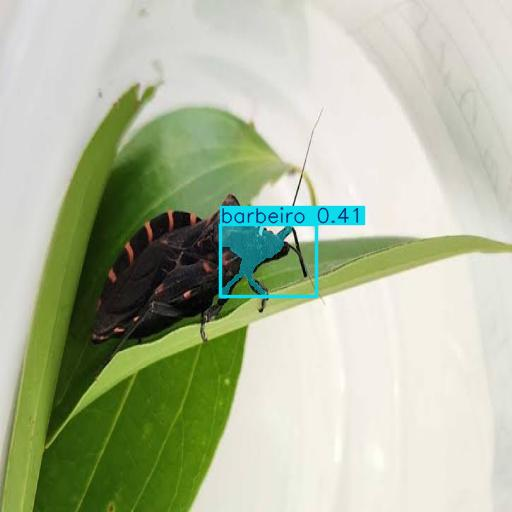

------------------------------------------------------------


In [4]:
import os
import cv2
from IPython.display import Image, display
from PIL import Image as PILImage

# Caminho automático para as imagens de validação do Roboflow
base_image_dir = os.path.join(dataset.location, "valid", "images")

if os.path.exists(base_image_dir):
    image_files = [f for f in os.listdir(base_image_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    if image_files:
        # Testa as 5 primeiras imagens da pasta para avaliar os resultados
        imagens_para_testar = image_files[:5]
        print(f"[INFO] Testando {len(imagens_para_testar)} imagens com filtros de sensibilidade máxima...\n")

        for idx, image_filename in enumerate(imagens_para_testar):
            image_path = os.path.join(base_image_dir, image_filename)
            print(f"--- [Foto {idx+1}] {image_filename} ---")

            # FILTROS DE PREDIÇÃO ULTRA-SENSÍVEIS:
            # conf=0.10     -> Pega até os objetos que o modelo tem certa dúvida
            # iou=0.35      -> Separa com precisão objetos muito colados uns nos outros
            # augment=True  -> Ativa o TTA (faz o modelo analisar a foto em múltiplos ângulos antes de responder)
            results = model.predict(image_path, save=True, conf=0.10, iou=0.35, augment=True)

            if results and len(results[0].boxes) > 0:
                detectados = []
                for box in results[0].boxes:
                    class_id = int(box.cls[0])
                    label = model.names[class_id]
                    confidence = float(box.conf[0])
                    detectados.append(label)
                    print(f"   ↳ {label} detectado! Confiança: {confidence:.2f}")

                # Diagnóstico amigável das classes encontradas
                lista_classes = str(detectados).lower()
                if "acai" in lista_classes and "barbeiro" in lista_classes:
                    print("   🎉 Perfeito! Açaí E Barbeiro encontrados na mesma imagem.")
                elif "barbeiro" in lista_classes:
                    print("   ⚠️ Apenas o Barbeiro foi visto. O Açaí sumiu ou não existe nesta foto.")
                else:
                    print("   ⚠️ Apenas o Açaí foi visto. O Barbeiro sumiu ou não existe nesta foto.")

                # Plota, converte as cores e exibe na tela
                img_with_preds = results[0].plot()
                img_rgb = cv2.cvtColor(img_with_preds, cv2.COLOR_BGR2RGB)

                sampled_img = PILImage.fromarray(img_rgb)
                nome_resultado = f"resultado_final_{idx}.jpg"
                sampled_img.save(nome_resultado)

                display(Image(nome_resultado))
                print("-" * 60)
            else:
                print("   ❌ Nenhum objeto (Açaí/Barbeiro) foi encontrado mesmo com sensibilidade alta.\n")
    else:
        print(f"Nenhuma imagem encontrada em: {base_image_dir}")
else:
    print("Diretório de validação não encontrado.")